## Histological Tissue Classification using CNN

## Supervised Machine Learning on PathMNIST

This notebook implements supervised learning methods to classify histopathology image patches from the PathMNIST dataset.

The objectives are:
1. Perform appropriate data preprocessing.
2. Train and evaluate a deep neural network classifier.
3. Implement hyperparameter optimisation.
4. Compare performance against a logistic regression baseline.

In [ ]:
# Installing required packages

!pip3 install numpy pandas matplotlib seaborn scikit-learn torch torchvision


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [3]:
# Data Processing packages
import numpy as np
import pandas as pd
import random

import os
import os.path

# Visualisation packages
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning packages
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Deep Learning packages
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
torch.set_num_threads(2) # this makes it run better on elab

## 1. Reproducibility and Environment Setup

To ensure reproducibility, fixed random seeds are used for NumPy and PyTorch.  
GPU acceleration is enabled where available.

#### Seed for Machine Learning

Seed generates a psuedo-random number which is essential for Machine Learning models.
It helps the code to generate the same initial data splits, weights, and shuffles everytime.
This ensures identical model results across multiple results.

In [4]:
seed = 42
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [5]:
# this allows pytorch to use a GPU, if one is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


## 2. Data Loading and Exploration

The dataset consists of 28×28 RGB histopathology image patches from nine tissue classes.  
A separate test dataset was collected from a different spatial location.

We first inspect dataset structure and class distribution.

In [6]:
data = np.load('./Assignment1Data.npz')

In [7]:
data.files

['train_images', 'train_labels', 'test_images', 'test_labels']

Once the data have been loaded, assign each of the training, validation and test sets to their own array

In [8]:
train_data = data['train_images']
train_labels = data['train_labels']
test_data = data['test_images']
test_labels = data['test_labels']

In [9]:
label_dict = {
            0: "adipose",
            1: "lymphocytes",
            2: "normal colon mucosa",
            3: "cancer-associated stroma",
            4: "colorectal adenocarcinoma epithelium"
        }

In [10]:
print(f'Train images shape : {train_data.shape}')
print(f'Train labels shape : {train_labels.shape}')
print(f'Test  images shape : {test_data.shape}')
print(f'Test  labels shape : {test_labels.shape}')

Train images shape : (55490, 28, 28, 3)
Train labels shape : (55490, 1)
Test  images shape : (4367, 28, 28, 3)
Test  labels shape : (4367, 1)


### Imbalance Dataset check

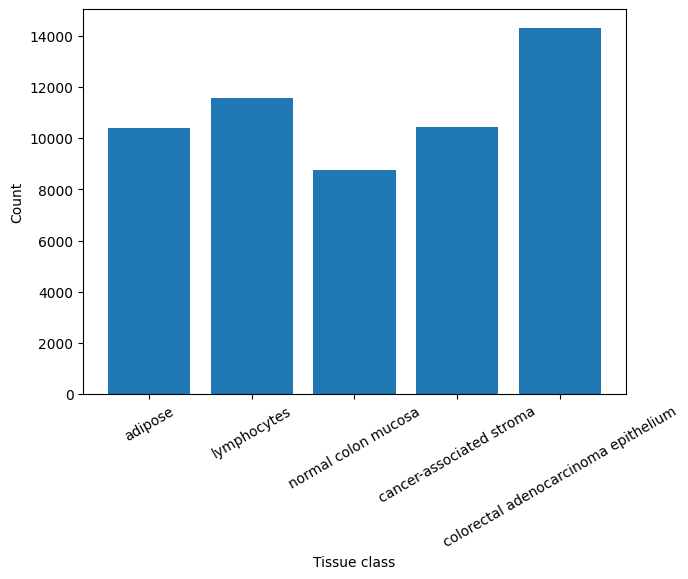

Class: adipose has count: 10407
Class: lymphocytes has count: 11557
Class: normal colon mucosa has count: 8763
Class: cancer-associated stroma has count: 10446
Class: colorectal adenocarcinoma epithelium has count: 14317


In [11]:
# lets check class distribution to make sure that the dataset is not imbalanced
values, counts = np.unique(train_labels, return_counts=True)

plt.figure(figsize=(7,5))
plt.bar([label_dict[v] for v in values], counts)
plt.xlabel('Tissue class')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

# printing the values and count of each label
for i in range(len(values)):
    print(f'Class: {label_dict[values[i]]} has count: {counts[i]}')

The above bar chart shows that the data is not imbalanced. Therefore, our model will not be biased towards a specific class of images.

**View an example image and its label**
note that each image is of size 28x28x3. The 28 corresponds to the height and width of the image in pixels. There are 3 channels, corresponding to the amount of Red, Green, and Blue in each pixel. 

In [12]:
label1 = train_labels[0]
label_dict[label1[0]]

'adipose'

Text(0.5, 0.01, 'adipose')

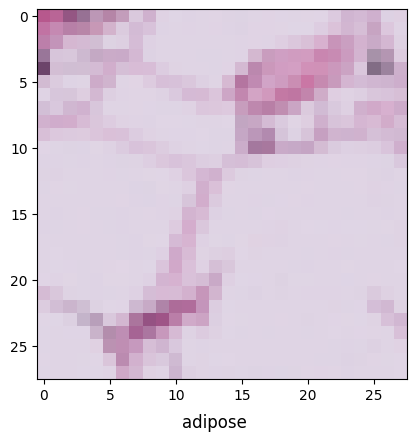

In [13]:
image1 = train_data[0,:,:,:]
plt.imshow(image1)
plt.figtext(0.5, 0.01, label_dict[label1[0]], wrap=True, horizontalalignment='center', fontsize=12)

We can look at each channel individually if we wish, by just plotting one of the layers:

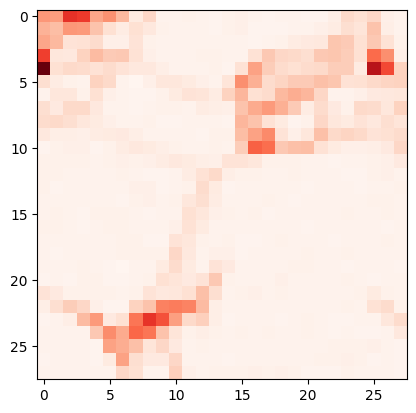

In [14]:
plt.imshow(train_data[0,:,:,0],cmap='Reds_r')

Plotting an image of each class of cell

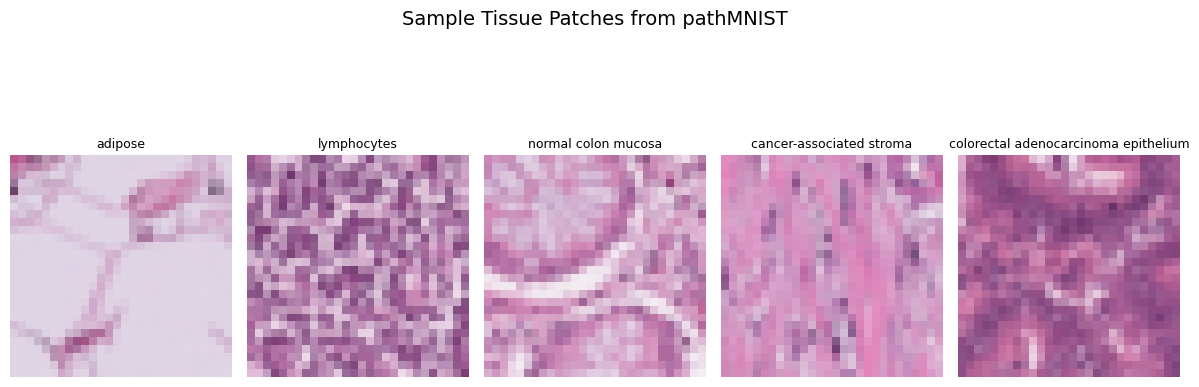

In [15]:
plt.figure(figsize=(12, 5))

for i in range(5):
    idx = np.where(train_labels == i)[0][0]
    plt.subplot(1, 5, i + 1)
    plt.imshow(train_data[idx])
    plt.title(label_dict[i], fontsize=9, pad=6)
    plt.axis('off')

plt.suptitle("Sample Tissue Patches from pathMNIST", fontsize=14)
plt.tight_layout()
plt.show()

## Train using SKlearn

This data is now in a format that can be used for SKlearn models (although there has been no pre-processing, etc).

We have further processed the data here to take the average of the three (R,G,B) channels to output one (grayscale) channel. You may wish to consider whether to use this grayscale image, or the raw RGB in your classifiers.

**model training - pseudocode below**

model = MyClassifier()

model.fit(train_1d, y)

## 3. Baseline Model: Logistic Regression (RGB)

Images are flattened into feature vectors and standardised using z-score normalisation.  
The scaler is fitted on the training data only to prevent information leakage.

In [16]:
## use the sum of channels of each image, and reshape the data into a 1-D array (instead of the 2D image array)

train_data_rgb = np.empty((len(train_data), 28*28))
for i in range(len(train_data)):
    train_data_rgb[i,:] = np.reshape((train_data[i,:,:,0] + train_data[i,:,:,1] + train_data[i,:,:,2])/3 , -1)

In [17]:
test_data_rgb = np.empty((len(test_data), 28*28))
for i in range(len(test_data)):
   test_data_rgb[i,:] = np.reshape((test_data[i,:,:,0] + test_data[i,:,:,1] + test_data[i,:,:,2])/3, -1)

In [18]:
"""
Flattening labels
"""

train_labels = train_labels.ravel()
test_labels = test_labels.ravel()

### Traing and Validation Split

A validation set is crucial in machine learning for detecting overfitting, fine-tuning hyperparameters, and selecting the best-performing model on unseen data.

In [19]:
# RGB Split

train_rgb, val_rgb, train_label_rgb, val_label_rgb = train_test_split(
                                                        train_data_rgb, 
                                                        train_labels, test_size=0.2, 
                                                        random_state=42, stratify=train_labels)

print(f"Shape of training set: {train_rgb.shape} with label shape: {train_label_rgb.shape}")
print(f"Shape of validation set: {val_rgb.shape} with label shape: {val_label_rgb.shape}")
print(f"Shape of testing data: {test_data_rgb.shape} with label: {test_labels.shape}")

Shape of training set: (44392, 784) with label shape: (44392,)
Shape of validation set: (11098, 784) with label shape: (11098,)
Shape of testing data: (4367, 784) with label: (4367,)


In [20]:
# Standardize the features (important for Logistic Regression)
scaler = StandardScaler()

train_rgb_scaled = scaler.fit_transform(train_rgb)
val_rgb_scaled = scaler.transform(val_rgb)
test_rgb_scaled = scaler.transform(test_data_rgb)

In [21]:
log_reg = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    n_jobs=-1,
    )

log_reg.fit(train_rgb_scaled, train_label_rgb)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [22]:
# Validate dataset
val_pred_rgb = log_reg.predict(val_rgb_scaled)
val_acc_rgb = accuracy_score(val_label_rgb, val_pred_rgb)

print(f"Final Logistic Regression (RGB) Validation Accuracy: {val_acc_rgb:.3f}")

Final Logistic Regression (RGB) Validation Accuracy: 0.318


In [23]:
# Testing dataset
test_pred_rgb = log_reg.predict(test_rgb_scaled)
test_acc_rgb = accuracy_score(test_labels, test_pred_rgb)

print(f"Final Logistic Regression (RGB) Test Accuracy: {test_acc_rgb:.3f}")

Final Logistic Regression (RGB) Test Accuracy: 0.226


## Classification metrics
The next two cells are commented out template code to see how well it does on the test set. Note that it will not currently work, as the model has not been defined or trained.

In [24]:
print(classification_report(test_labels, test_pred_rgb))

              precision    recall  f1-score   support

           0       0.12      0.04      0.06      1338
           1       0.18      0.19      0.19       634
           2       0.25      0.10      0.15       741
           3       0.17      0.28      0.22       421
           4       0.27      0.50      0.35      1233

    accuracy                           0.23      4367
   macro avg       0.20      0.22      0.19      4367
weighted avg       0.20      0.23      0.19      4367



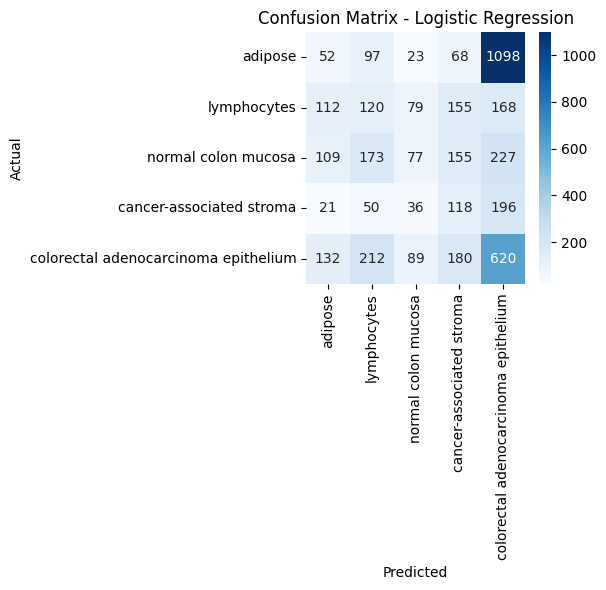

In [25]:
plt.figure(figsize=(6,6))
sns.heatmap(
    confusion_matrix(test_labels, test_pred_rgb), 
    fmt='d', 
    annot=True,
    cmap='Blues',
    xticklabels=[label_dict[i] for i in range(len(label_dict))],
    yticklabels=[label_dict[i] for i in range(len(label_dict))]
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 4. Baseline Model: Logistic Regression (Grayscale)

To evaluate the impact of colour information, grayscale images are also used.  
This reduces dimensionality while retaining structural information.

In [26]:
"""
    First we need to normalise the pixel values because each pixel
    In digital images, pixel intensities range from 0 (black) to 255 (white). 
    By dividing every pixel by 255, you squash the data into a range between 0.0 and 1.0.
    It ensures that the code can run faster.
    It also ensures that all input features are on the same scale, which helps the mathematical optimization stay stable.
    Images are normalised to the range [0, 1] to stabilise gradient-based optimisation and improve convergence of neural networks.
"""

train_data_gray = train_data.astype('float32') / 255.0
test_data_gray = test_data.astype('float32') / 255.0

In [27]:
## use the sum of channels of each image, and reshape the data into a 1-D array (instead of the 2D image array) but grayscale

train_data_gray_flat = train_data_gray.reshape(train_data_gray.shape[0], -1)
test_data_gray_flat = test_data_gray.reshape(test_data_gray.shape[0], -1)

In [28]:
# Grayscale Split

train_gray, val_gray, train_label_gray, val_label_gray = train_test_split(
                                                        train_data_gray_flat, 
                                                        train_labels, test_size=0.2, 
                                                        random_state=42, stratify=train_labels)

print(f"Shape of training set: {train_gray.shape} with label shape: {train_label_gray.shape}")
print(f"Shape of validation set: {val_gray.shape} with label shape: {val_label_gray.shape}")
print(f"Shape of testing data: {test_data_gray_flat.shape} with label: {test_labels.shape}")

Shape of training set: (44392, 2352) with label shape: (44392,)
Shape of validation set: (11098, 2352) with label shape: (11098,)
Shape of testing data: (4367, 2352) with label: (4367,)


In [29]:
scaler_gray = StandardScaler()

train_gray_scaled = scaler_gray.fit_transform(train_gray)
val_gray_scaled = scaler_gray.transform(val_gray)
test_gray_scaled = scaler_gray.transform(test_data_gray_flat)

In [31]:
log_reg_gray = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    n_jobs=-1,
    
)

log_reg_gray.fit(train_gray_scaled, train_label_gray)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [32]:
# Validate dataset
val_pred_gray = log_reg_gray.predict(val_gray_scaled)
val_acc_gray = accuracy_score(val_label_gray, val_pred_gray)

print(f"Logistic Regression (Grayscale) Validation Accuracy: {val_acc_gray:.3f}")

Logistic Regression (Grayscale) Validation Accuracy: 0.706


In [33]:
# Testing dataset
test_pred_gray = log_reg_gray.predict(test_gray_scaled)
test_acc_gray = accuracy_score(test_labels, test_pred_gray)

print(f"Final Logistic Regression (Grayscale) Test Accuracy: {test_acc_gray:.3f}")

Final Logistic Regression (Grayscale) Test Accuracy: 0.672


In [34]:
print(classification_report(test_labels, test_pred_gray))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      1338
           1       0.47      0.51      0.49       634
           2       0.50      0.27      0.35       741
           3       0.89      0.64      0.74       421
           4       0.55      0.68      0.61      1233

    accuracy                           0.67      4367
   macro avg       0.66      0.61      0.63      4367
weighted avg       0.67      0.67      0.66      4367



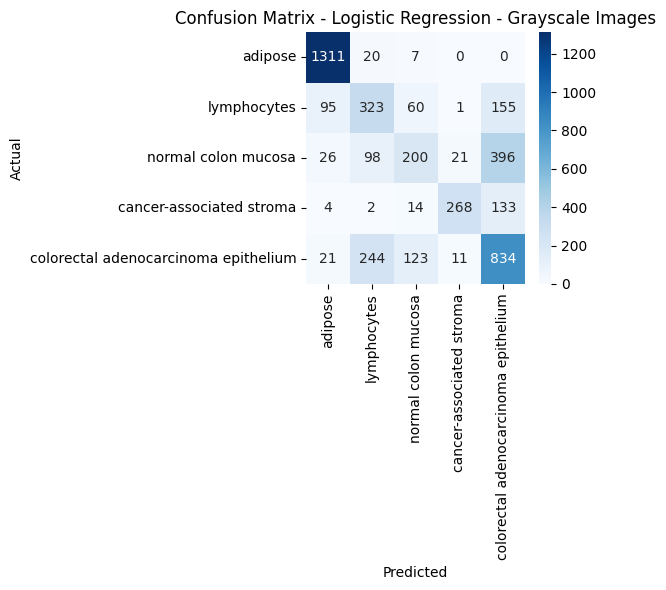

In [35]:
plt.figure(figsize=(6,6))
sns.heatmap(
    confusion_matrix(test_labels, test_pred_gray), 
    fmt='d', 
    annot=True,
    cmap='Blues',
    xticklabels=[label_dict[i] for i in range(len(label_dict))],
    yticklabels=[label_dict[i] for i in range(len(label_dict))]
)

plt.title('Confusion Matrix - Logistic Regression - Grayscale Images')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 5. Deep Learning Model: Convolutional Neural Network

A CNN is implemented to leverage spatial feature extraction.  
Images are normalised to the range [0,1] and converted to PyTorch tensors.

The model consists of:
- Two convolutional blocks (Conv → ReLU → MaxPool)
- Fully connected output layer (9 classes)

## Data format for PyTorch

To train a model using Pytorch, we need to convert our data into tensors. We can think of tensor as a multidimensional array. We use tensors, rather than an np.array, as the data type is optimised for GPUs.

It is a bit fiddly to convert the data, so we've done it for you below (note that this is overwriting the variables used previously). 

We've also copied across the CNN similar to the one used in the labs previously to make your life slightly easier.

We have only used a training dataset below, we have not split the training data into a validation and training dataset for you. 

In [36]:
train_dl, val_dl, train_label_dl, val_label_dl = train_test_split(
                                                        train_data, 
                                                        train_labels, test_size=0.2, 
                                                        random_state=42, stratify=train_labels
                                                    )

print(f"Shape of training set: {train_dl.shape} with label shape: {train_label_dl.shape}")
print(f"Shape of validation set: {val_dl.shape} with label shape: {val_label_dl.shape}")
print(f"Shape of testing data: {test_data.shape} with label: {test_labels.shape}")

Shape of training set: (44392, 28, 28, 3) with label shape: (44392,)
Shape of validation set: (11098, 28, 28, 3) with label shape: (11098,)
Shape of testing data: (4367, 28, 28, 3) with label: (4367,)


In [37]:
def torch_format_data(data_name, label_name, device):
    t_data = data_name
    # t_data = np.mean(t_data, -1)/256
    t_data = np.mean(t_data, -1) / 255.0
    t_data = np.expand_dims(t_data,1)
    # labels = label_name # Redundant line
    # labels = label_name.squeeze(1) # We have already flattened the labels above and kept the same name
    
    t_data = torch.tensor(t_data, dtype=torch.float, device=device)
    labels = torch.tensor(label_name, dtype=torch.long, device=device)
    dataset = torch.utils.data.TensorDataset(t_data, labels)
    return dataset

In [38]:
train_set = torch_format_data(train_dl, train_label_dl, device)
val_set = torch_format_data(val_dl, val_label_dl, device)
test_set = torch_format_data(test_data, test_labels, device)

In [39]:
print(type(train_set))
print(type(val_set))
print(type(test_set))

<class 'torch.utils.data.dataset.TensorDataset'>
<class 'torch.utils.data.dataset.TensorDataset'>
<class 'torch.utils.data.dataset.TensorDataset'>


In [40]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Sequential(         
            nn.Conv2d(
                in_channels=1,              
                out_channels=16,            
                kernel_size=5,              
                stride=1,                   
                padding=2,                  
            ),                              
            nn.ReLU(),                      
            nn.MaxPool2d(kernel_size=2),    
        )
        self.conv2 = nn.Sequential(         
            nn.Conv2d(16, 32, 5, 1, 2),     
            nn.ReLU(),                      
            nn.MaxPool2d(2),                
        )
        # # fully connected layer, output 9 classes
        # self.out = nn.Linear(32 * 7 * 7, 9)

        self.out = nn.Linear(32 * 7 * 7, 5)     # Because there are only 5 classes
            

        
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        
        # flatten the output of conv2 to (batch_size, 32 * 7 * 7)
        x = x.view(x.size(0), -1)       
        output = self.out(x)
        return output    # return x for visualization

In [41]:
def train(num_epochs, cnn, loaders, loss_func, optimizer): # added missing parameters    
    # Train the model
    total_step = len(loaders['train'])
    train_losses = []
    val_losses = []
        
    for epoch in range(num_epochs):
        # this sets the model mode - (i.e. layers like dropout, batchnorm etc behave differently during training compared to testing)
        # note that this function was not defined explicitly in CNN, but because CNN is a type of nn.Module, it inherits some functions
        # from the more general nn class.
        train_losses = []
    val_losses = []

    for epoch in range(num_epochs):

        # TRAINING
        cnn.train()
        running_loss = 0.0

        for i, (image, label) in enumerate(loaders['train']):

            image, label = image.to(device), label.to(device)

            optimizer.zero_grad()
            output = cnn(image)
            loss = loss_func(output, label)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_train_loss = running_loss / len(loaders['train'])
        train_losses.append(epoch_train_loss)

        # VALIDATION
        cnn.eval()
        val_loss = 0.0

        with torch.no_grad():
            for images, labels in loaders['val']:
                images, labels = images.to(device), labels.to(device)
                output = cnn(images)
                loss = loss_func(output, labels)
                val_loss += loss.item()

        epoch_val_loss = val_loss / len(loaders['val'])
        val_losses.append(epoch_val_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {epoch_train_loss:.4f} "
              f"Val Loss: {epoch_val_loss:.4f}")

    # Plot once at end
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.legend()
    plt.title("Training vs Validation Loss")
    plt.show()

    return train_losses, val_losses

### Creating a sample Deep Learning model

In [42]:
cnn = CNN().to(device)  # in case we use GPU later
loss_func = nn.CrossEntropyLoss()   

optimizer = optim.Adam(cnn.parameters(), lr = 0.001)

BATCH_SIZE = 64

loaders = {
    'train' : DataLoader(train_set, 
                            batch_size=BATCH_SIZE, 
                            shuffle=True, 
                            num_workers=1),
    
    'val': DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=1),
    
    'test'  : DataLoader(test_set, 
                            batch_size=BATCH_SIZE, 
                            shuffle=True, 
                            num_workers=1),
}

Epoch [1/10] Train Loss: 0.8786 Val Loss: 0.6409
Epoch [2/10] Train Loss: 0.6410 Val Loss: 0.5629
Epoch [3/10] Train Loss: 0.5730 Val Loss: 0.5360
Epoch [4/10] Train Loss: 0.5378 Val Loss: 0.5009
Epoch [5/10] Train Loss: 0.5072 Val Loss: 0.5284
Epoch [6/10] Train Loss: 0.4858 Val Loss: 0.5114
Epoch [7/10] Train Loss: 0.4580 Val Loss: 0.4233
Epoch [8/10] Train Loss: 0.4451 Val Loss: 0.4385
Epoch [9/10] Train Loss: 0.4321 Val Loss: 0.4421
Epoch [10/10] Train Loss: 0.4115 Val Loss: 0.3880


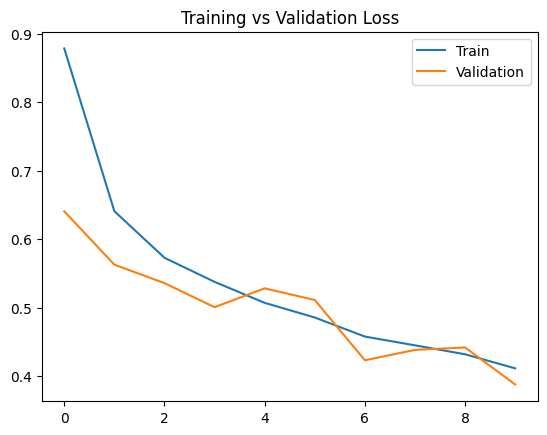

([0.8786387181161803,
  0.6410206198177008,
  0.5730397121964683,
  0.5378254760668669,
  0.5072140644495013,
  0.4857916861386052,
  0.45797576072494306,
  0.4451462350334833,
  0.4321180103663409,
  0.41153271337407465],
 [0.6408561363644983,
  0.5629387751392935,
  0.5359744179522854,
  0.5008620734529934,
  0.5283773286246706,
  0.5113511263639078,
  0.4233441984002618,
  0.4385026242883726,
  0.44206575227194816,
  0.3879973965472189])

In [43]:
num_epochs = 10

train(num_epochs, cnn, loaders, loss_func, optimizer)

In [46]:
def test(cnn):
    # Test the model
    cnn.eval()
    all_preds = []
    all_labels = []
    correct = 0
    total = 0

    with torch.no_grad():
        for i, (image, label) in enumerate(loaders['test']):  # to keep it consistent with above
            image, label = image.to(device), label.to(device) # in case we use GPU later
            
            test_output = cnn(image) ## this runs the trained cnn. Note from the cnn class, test_output gives the model output (10 x 1 values), and last_layer gives the inputs into the last layer
            ## torch.max finds the highest value of test_output. the [0] array element returns the maximum value, the [1] element
            ## gives the index of that element. squeeze reshapes the data from a nx1 array into a list
            pred_y = torch.max(test_output, 1)[1].data.squeeze() 
            
            correct += (pred_y == label).sum().item()
            total += float(label.size(0))

            all_preds.extend(pred_y.cpu().numpy())
            all_labels.extend(label.cpu().numpy())
            
        # pass
        accuracy = correct / total
        print(f"Test Accuracy of the model on the test images: {accuracy:.3f}")
    
    # pass

    # plot confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    return (correct / total, all_preds, all_labels)

Test Accuracy of the model on the test images: 0.859


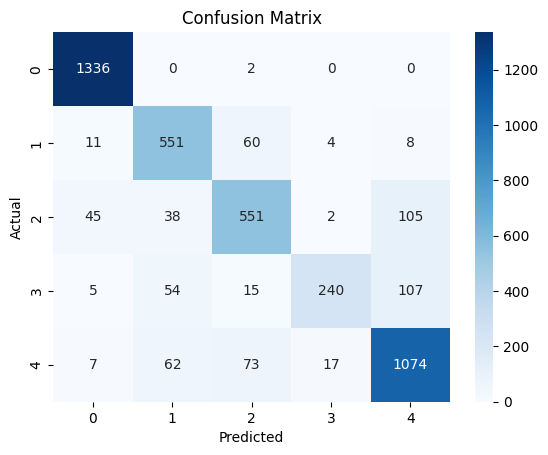

(0.8591710556446073,
 [np.int64(2),
  np.int64(0),
  np.int64(0),
  np.int64(4),
  np.int64(4),
  np.int64(0),
  np.int64(4),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(2),
  np.int64(1),
  np.int64(4),
  np.int64(3),
  np.int64(3),
  np.int64(4),
  np.int64(3),
  np.int64(2),
  np.int64(1),
  np.int64(4),
  np.int64(2),
  np.int64(1),
  np.int64(2),
  np.int64(1),
  np.int64(2),
  np.int64(4),
  np.int64(0),
  np.int64(3),
  np.int64(2),
  np.int64(2),
  np.int64(1),
  np.int64(4),
  np.int64(2),
  np.int64(0),
  np.int64(2),
  np.int64(4),
  np.int64(0),
  np.int64(0),
  np.int64(2),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(4),
  np.int64(0),
  np.int64(0),
  np.int64(4),
  np.int64(4),
  np.int64(4),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(2),
  np.int64(4),
  np.int64(4),
  np.int64(1),
  np.int64(0),
  np.int64(2),
  np.int64(3),
  np.int64(4),
  np.int64(2),
  np.int64(1),
  np.int64(1),
  np.int64(4),
  np.int64(0),
  np

In [47]:
test(cnn)

## 6. Hyperparameter Optimisation

A grid-based search is conducted over:

- Optimisers: SGD, Adam, AdamW  
- Learning rates: 0.01, 0.001, 0.0001  
- Epochs: 10 and 20

Each configuration is trained independently, and performance is recorded.

Epoch [1/10] Train Loss: 1.5997 Val Loss: 1.5952
Epoch [2/10] Train Loss: 1.5926 Val Loss: 1.5891
Epoch [3/10] Train Loss: 1.5848 Val Loss: 1.5789
Epoch [4/10] Train Loss: 1.5664 Val Loss: 1.5491
Epoch [5/10] Train Loss: 1.5215 Val Loss: 1.4827
Epoch [6/10] Train Loss: 1.4223 Val Loss: 1.3497
Epoch [7/10] Train Loss: 1.2781 Val Loss: 1.2122
Epoch [8/10] Train Loss: 1.1758 Val Loss: 1.1461
Epoch [9/10] Train Loss: 1.1246 Val Loss: 1.1052
Epoch [10/10] Train Loss: 1.0978 Val Loss: 1.0806


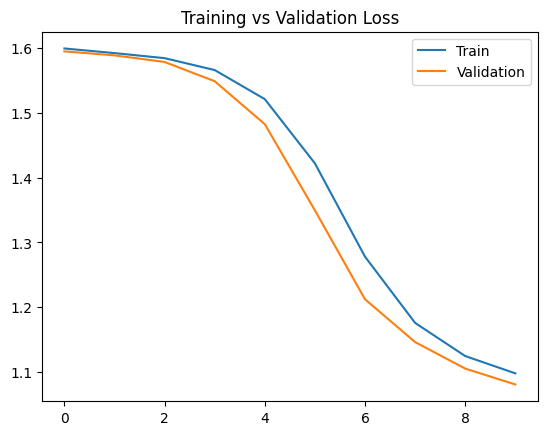

Test Accuracy of the model on the test images: 0.530


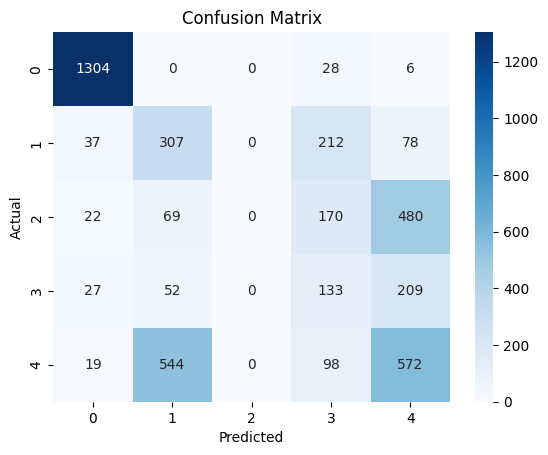

Optimiser: SGD, Learning rate: 0.001 -> Accuracy: 0.530
Epoch [1/10] Train Loss: 1.5141 Val Loss: 1.2560
Epoch [2/10] Train Loss: 1.2482 Val Loss: 1.2563
Epoch [3/10] Train Loss: 1.0973 Val Loss: 1.0651
Epoch [4/10] Train Loss: 1.0156 Val Loss: 1.1026
Epoch [5/10] Train Loss: 0.9356 Val Loss: 0.8582
Epoch [6/10] Train Loss: 0.8734 Val Loss: 0.9130
Epoch [7/10] Train Loss: 0.8223 Val Loss: 0.7568
Epoch [8/10] Train Loss: 0.7917 Val Loss: 0.7755
Epoch [9/10] Train Loss: 0.7771 Val Loss: 0.7580
Epoch [10/10] Train Loss: 0.7570 Val Loss: 0.7208


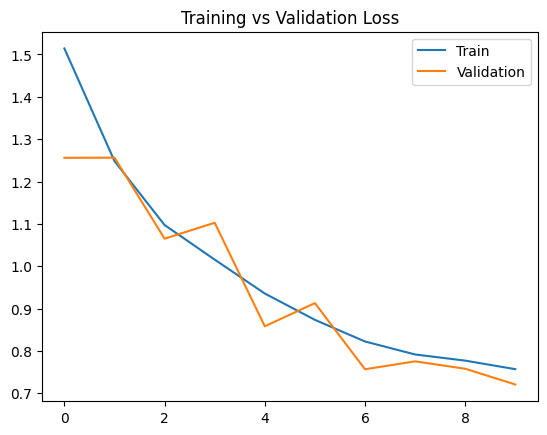

Test Accuracy of the model on the test images: 0.713


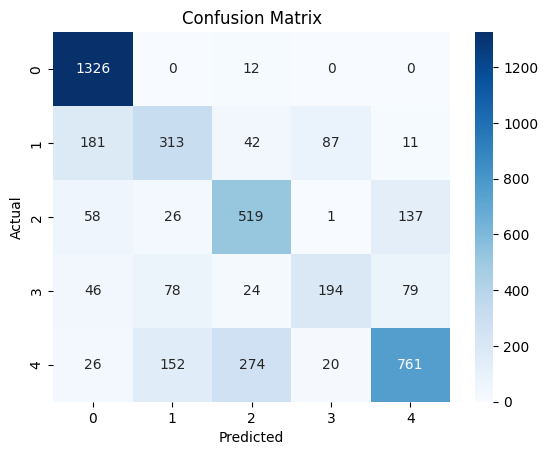

Optimiser: SGD, Learning rate: 0.01 -> Accuracy: 0.713
Epoch [1/10] Train Loss: 1.6025 Val Loss: 1.6009
Epoch [2/10] Train Loss: 1.6001 Val Loss: 1.5994
Epoch [3/10] Train Loss: 1.5989 Val Loss: 1.5983
Epoch [4/10] Train Loss: 1.5981 Val Loss: 1.5977
Epoch [5/10] Train Loss: 1.5975 Val Loss: 1.5972
Epoch [6/10] Train Loss: 1.5970 Val Loss: 1.5965
Epoch [7/10] Train Loss: 1.5965 Val Loss: 1.5962
Epoch [8/10] Train Loss: 1.5959 Val Loss: 1.5956
Epoch [9/10] Train Loss: 1.5955 Val Loss: 1.5952
Epoch [10/10] Train Loss: 1.5949 Val Loss: 1.5946


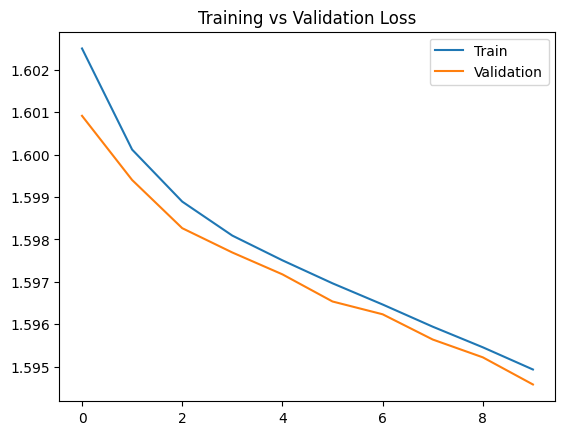

Test Accuracy of the model on the test images: 0.282


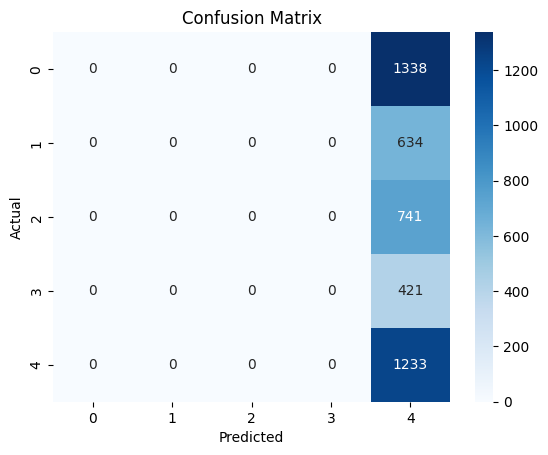

Optimiser: SGD, Learning rate: 0.0001 -> Accuracy: 0.282
Epoch [1/10] Train Loss: 0.9017 Val Loss: 0.6967
Epoch [2/10] Train Loss: 0.6204 Val Loss: 0.5524
Epoch [3/10] Train Loss: 0.5543 Val Loss: 0.5034
Epoch [4/10] Train Loss: 0.5161 Val Loss: 0.5403
Epoch [5/10] Train Loss: 0.4797 Val Loss: 0.4649
Epoch [6/10] Train Loss: 0.4634 Val Loss: 0.4239
Epoch [7/10] Train Loss: 0.4332 Val Loss: 0.5315
Epoch [8/10] Train Loss: 0.4286 Val Loss: 0.4460
Epoch [9/10] Train Loss: 0.4076 Val Loss: 0.4189
Epoch [10/10] Train Loss: 0.4059 Val Loss: 0.4093


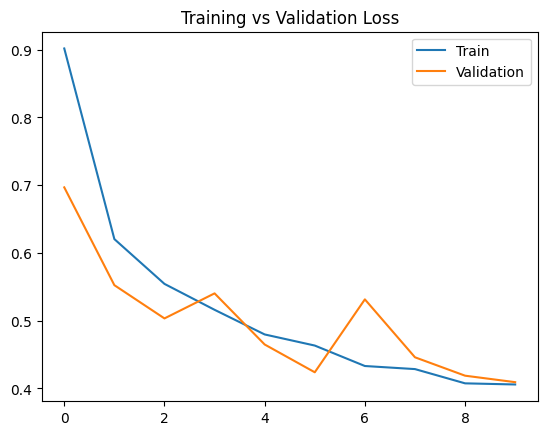

Test Accuracy of the model on the test images: 0.871


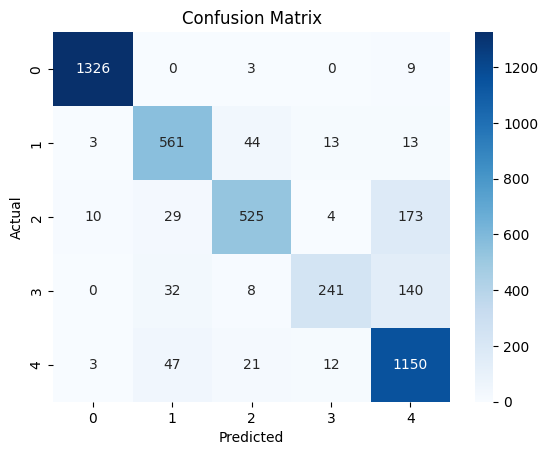

Optimiser: Adam, Learning rate: 0.001 -> Accuracy: 0.871
Epoch [1/10] Train Loss: 1.0221 Val Loss: 0.8887
Epoch [2/10] Train Loss: 0.8640 Val Loss: 0.8451
Epoch [3/10] Train Loss: 0.7672 Val Loss: 0.7759
Epoch [4/10] Train Loss: 0.6944 Val Loss: 0.7775
Epoch [5/10] Train Loss: 0.6532 Val Loss: 0.5976
Epoch [6/10] Train Loss: 0.6343 Val Loss: 0.6330
Epoch [7/10] Train Loss: 0.6117 Val Loss: 0.5952
Epoch [8/10] Train Loss: 0.5955 Val Loss: 0.6186
Epoch [9/10] Train Loss: 0.5892 Val Loss: 0.6443
Epoch [10/10] Train Loss: 0.5779 Val Loss: 0.6236


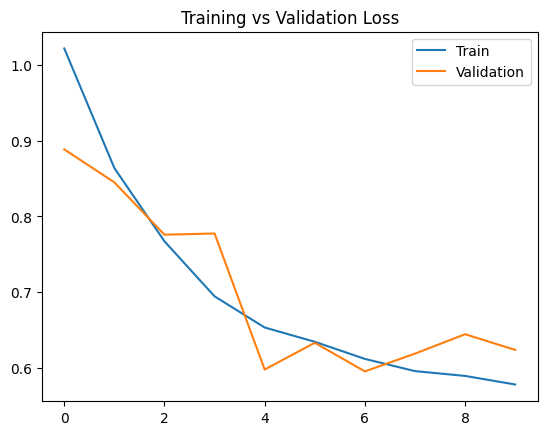

Test Accuracy of the model on the test images: 0.794


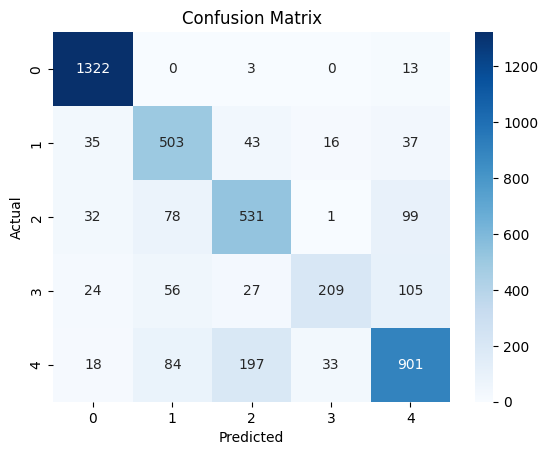

Optimiser: Adam, Learning rate: 0.01 -> Accuracy: 0.794
Epoch [1/10] Train Loss: 1.2246 Val Loss: 0.9787
Epoch [2/10] Train Loss: 0.9067 Val Loss: 0.8550
Epoch [3/10] Train Loss: 0.7992 Val Loss: 0.7484
Epoch [4/10] Train Loss: 0.7338 Val Loss: 0.7016
Epoch [5/10] Train Loss: 0.6943 Val Loss: 0.6992
Epoch [6/10] Train Loss: 0.6688 Val Loss: 0.6848
Epoch [7/10] Train Loss: 0.6476 Val Loss: 0.6351
Epoch [8/10] Train Loss: 0.6309 Val Loss: 0.6225
Epoch [9/10] Train Loss: 0.6173 Val Loss: 0.6320
Epoch [10/10] Train Loss: 0.6067 Val Loss: 0.6039


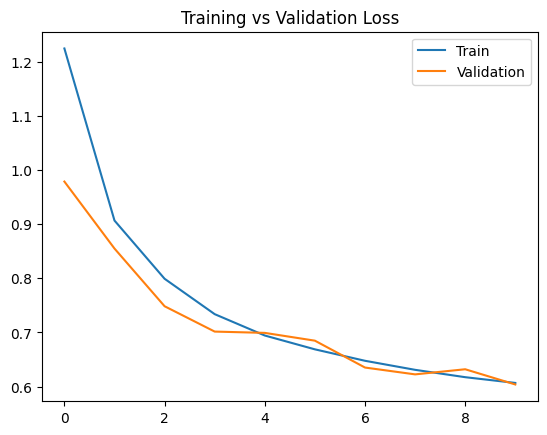

Test Accuracy of the model on the test images: 0.783


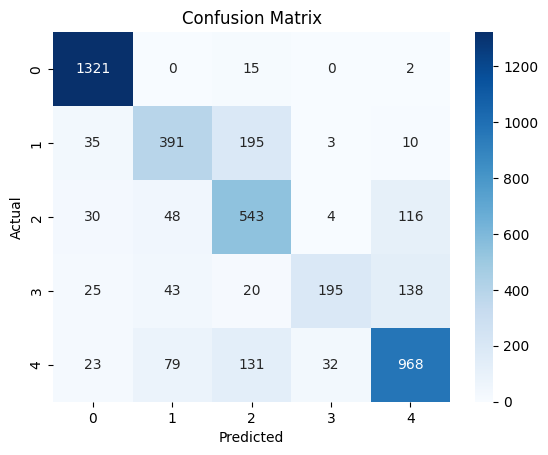

Optimiser: Adam, Learning rate: 0.0001 -> Accuracy: 0.783
Epoch [1/10] Train Loss: 0.9002 Val Loss: 0.6627
Epoch [2/10] Train Loss: 0.6421 Val Loss: 0.6023
Epoch [3/10] Train Loss: 0.5679 Val Loss: 0.6001
Epoch [4/10] Train Loss: 0.5306 Val Loss: 0.7158
Epoch [5/10] Train Loss: 0.5081 Val Loss: 0.5385
Epoch [6/10] Train Loss: 0.4756 Val Loss: 0.4754
Epoch [7/10] Train Loss: 0.4591 Val Loss: 0.4164
Epoch [8/10] Train Loss: 0.4482 Val Loss: 0.4230
Epoch [9/10] Train Loss: 0.4397 Val Loss: 0.4622
Epoch [10/10] Train Loss: 0.4330 Val Loss: 0.4250


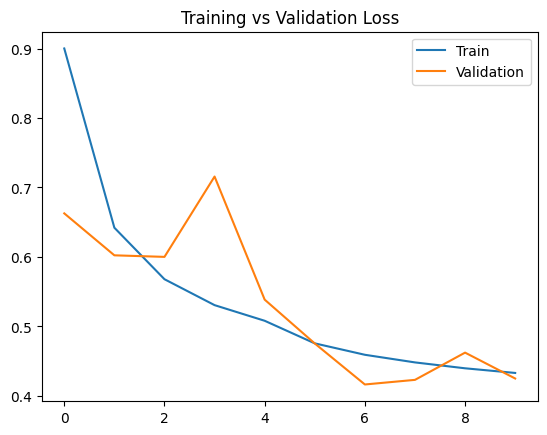

Test Accuracy of the model on the test images: 0.854


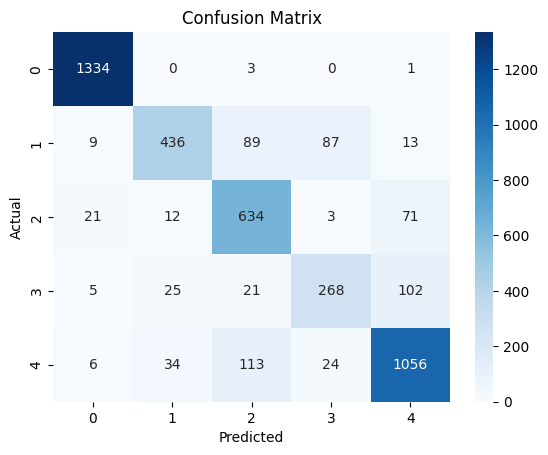

Optimiser: AdamW, Learning rate: 0.001 -> Accuracy: 0.854
Epoch [1/10] Train Loss: 1.5980 Val Loss: 1.5966
Epoch [2/10] Train Loss: 1.5966 Val Loss: 1.5967
Epoch [3/10] Train Loss: 1.5966 Val Loss: 1.5964
Epoch [4/10] Train Loss: 1.5966 Val Loss: 1.5967
Epoch [5/10] Train Loss: 1.5967 Val Loss: 1.5969
Epoch [6/10] Train Loss: 1.5967 Val Loss: 1.5963
Epoch [7/10] Train Loss: 1.5965 Val Loss: 1.5975
Epoch [8/10] Train Loss: 1.5965 Val Loss: 1.5966
Epoch [9/10] Train Loss: 1.5967 Val Loss: 1.5962
Epoch [10/10] Train Loss: 1.5965 Val Loss: 1.5964


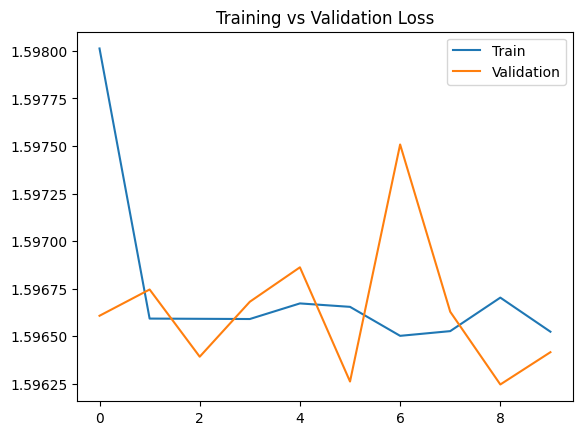

Test Accuracy of the model on the test images: 0.282


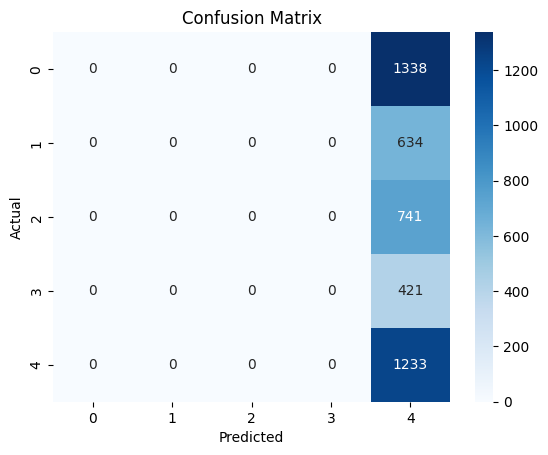

Optimiser: AdamW, Learning rate: 0.01 -> Accuracy: 0.282
Epoch [1/10] Train Loss: 1.2277 Val Loss: 0.9681
Epoch [2/10] Train Loss: 0.8873 Val Loss: 0.8208
Epoch [3/10] Train Loss: 0.7861 Val Loss: 0.7367
Epoch [4/10] Train Loss: 0.7220 Val Loss: 0.7031
Epoch [5/10] Train Loss: 0.6786 Val Loss: 0.6530
Epoch [6/10] Train Loss: 0.6518 Val Loss: 0.6411
Epoch [7/10] Train Loss: 0.6279 Val Loss: 0.6483
Epoch [8/10] Train Loss: 0.6124 Val Loss: 0.6008
Epoch [9/10] Train Loss: 0.5960 Val Loss: 0.5862
Epoch [10/10] Train Loss: 0.5851 Val Loss: 0.5792


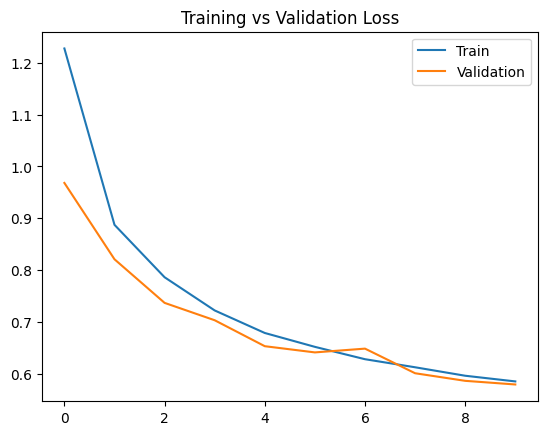

Test Accuracy of the model on the test images: 0.795


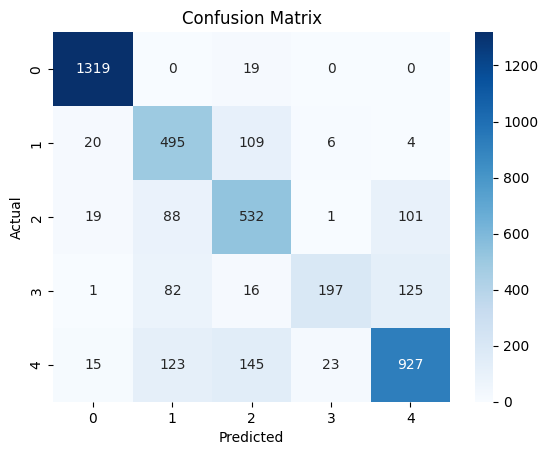

Optimiser: AdamW, Learning rate: 0.0001 -> Accuracy: 0.795
Epoch [1/20] Train Loss: 1.6000 Val Loss: 1.5944
Epoch [2/20] Train Loss: 1.5909 Val Loss: 1.5875
Epoch [3/20] Train Loss: 1.5826 Val Loss: 1.5768
Epoch [4/20] Train Loss: 1.5679 Val Loss: 1.5559
Epoch [5/20] Train Loss: 1.5359 Val Loss: 1.5084
Epoch [6/20] Train Loss: 1.4614 Val Loss: 1.4000
Epoch [7/20] Train Loss: 1.3294 Val Loss: 1.2579
Epoch [8/20] Train Loss: 1.2113 Val Loss: 1.1691
Epoch [9/20] Train Loss: 1.1486 Val Loss: 1.1274
Epoch [10/20] Train Loss: 1.1181 Val Loss: 1.1122
Epoch [11/20] Train Loss: 1.1003 Val Loss: 1.0876
Epoch [12/20] Train Loss: 1.0891 Val Loss: 1.0797
Epoch [13/20] Train Loss: 1.0799 Val Loss: 1.0728
Epoch [14/20] Train Loss: 1.0708 Val Loss: 1.0769
Epoch [15/20] Train Loss: 1.0633 Val Loss: 1.0600
Epoch [16/20] Train Loss: 1.0534 Val Loss: 1.0492
Epoch [17/20] Train Loss: 1.0446 Val Loss: 1.0352
Epoch [18/20] Train Loss: 1.0350 Val Loss: 1.0195
Epoch [19/20] Train Loss: 1.0235 Val Loss: 1.0077


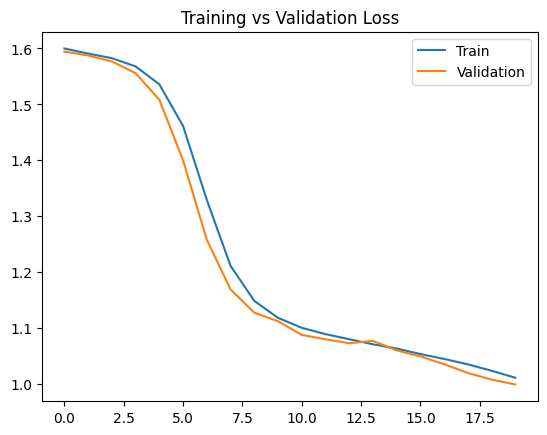

Test Accuracy of the model on the test images: 0.539


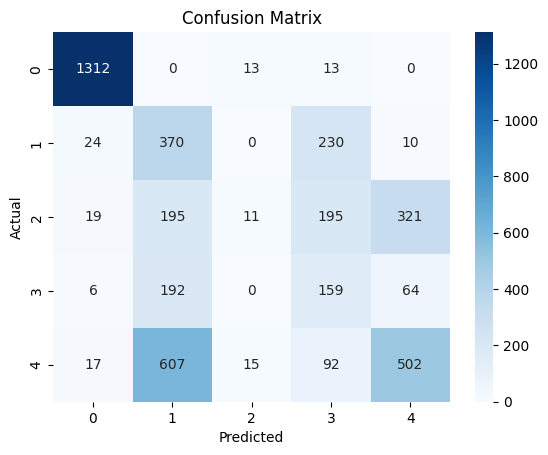

Optimiser: SGD, Learning rate: 0.001 -> Accuracy: 0.539
Epoch [1/20] Train Loss: 1.4622 Val Loss: 1.1753
Epoch [2/20] Train Loss: 1.2128 Val Loss: 1.0319
Epoch [3/20] Train Loss: 1.0891 Val Loss: 0.9837
Epoch [4/20] Train Loss: 1.0082 Val Loss: 1.0506
Epoch [5/20] Train Loss: 0.9501 Val Loss: 0.9255
Epoch [6/20] Train Loss: 0.8941 Val Loss: 0.7896
Epoch [7/20] Train Loss: 0.8398 Val Loss: 1.1635
Epoch [8/20] Train Loss: 0.8099 Val Loss: 0.8139
Epoch [9/20] Train Loss: 0.7792 Val Loss: 0.7806
Epoch [10/20] Train Loss: 0.7514 Val Loss: 0.7214
Epoch [11/20] Train Loss: 0.7381 Val Loss: 0.8196
Epoch [12/20] Train Loss: 0.7167 Val Loss: 0.7694
Epoch [13/20] Train Loss: 0.7018 Val Loss: 0.6948
Epoch [14/20] Train Loss: 0.6857 Val Loss: 0.8819
Epoch [15/20] Train Loss: 0.6803 Val Loss: 0.7951
Epoch [16/20] Train Loss: 0.6586 Val Loss: 0.7017
Epoch [17/20] Train Loss: 0.6416 Val Loss: 0.6162
Epoch [18/20] Train Loss: 0.6374 Val Loss: 0.6428
Epoch [19/20] Train Loss: 0.6240 Val Loss: 0.5922
Epo

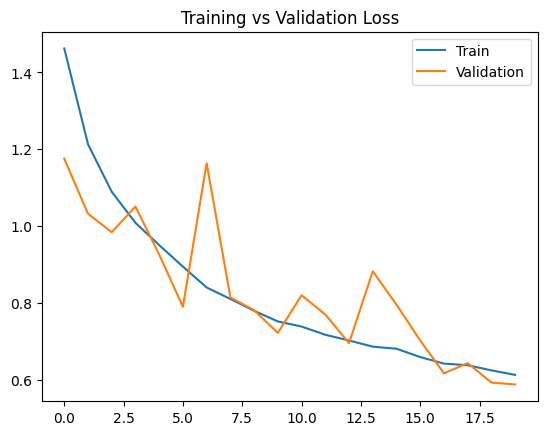

Test Accuracy of the model on the test images: 0.762


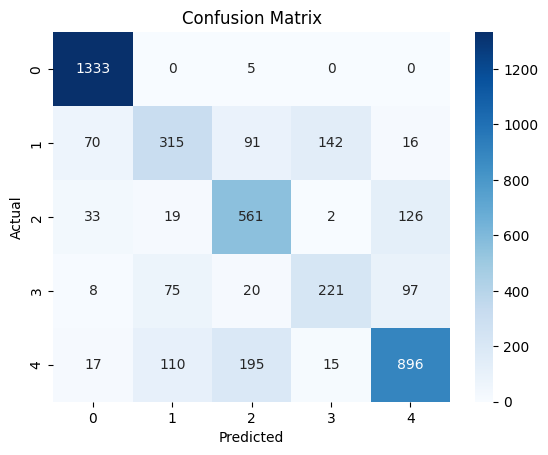

Optimiser: SGD, Learning rate: 0.01 -> Accuracy: 0.762
Epoch [1/20] Train Loss: 1.6075 Val Loss: 1.6030
Epoch [2/20] Train Loss: 1.6007 Val Loss: 1.5992
Epoch [3/20] Train Loss: 1.5981 Val Loss: 1.5976
Epoch [4/20] Train Loss: 1.5969 Val Loss: 1.5963
Epoch [5/20] Train Loss: 1.5960 Val Loss: 1.5957
Epoch [6/20] Train Loss: 1.5952 Val Loss: 1.5948
Epoch [7/20] Train Loss: 1.5945 Val Loss: 1.5942
Epoch [8/20] Train Loss: 1.5937 Val Loss: 1.5933
Epoch [9/20] Train Loss: 1.5929 Val Loss: 1.5927
Epoch [10/20] Train Loss: 1.5920 Val Loss: 1.5915
Epoch [11/20] Train Loss: 1.5911 Val Loss: 1.5908
Epoch [12/20] Train Loss: 1.5902 Val Loss: 1.5898
Epoch [13/20] Train Loss: 1.5892 Val Loss: 1.5889
Epoch [14/20] Train Loss: 1.5882 Val Loss: 1.5878
Epoch [15/20] Train Loss: 1.5871 Val Loss: 1.5866
Epoch [16/20] Train Loss: 1.5860 Val Loss: 1.5855
Epoch [17/20] Train Loss: 1.5848 Val Loss: 1.5841
Epoch [18/20] Train Loss: 1.5835 Val Loss: 1.5827
Epoch [19/20] Train Loss: 1.5821 Val Loss: 1.5812
Epoc

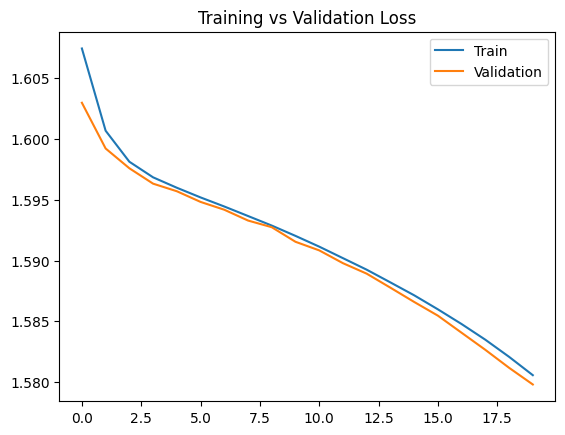

Test Accuracy of the model on the test images: 0.288


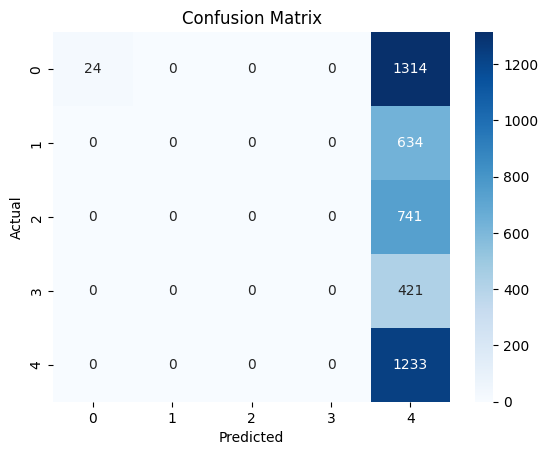

Optimiser: SGD, Learning rate: 0.0001 -> Accuracy: 0.288
Epoch [1/20] Train Loss: 0.8312 Val Loss: 0.6628
Epoch [2/20] Train Loss: 0.5918 Val Loss: 0.5407
Epoch [3/20] Train Loss: 0.5477 Val Loss: 0.4855
Epoch [4/20] Train Loss: 0.5118 Val Loss: 0.5174
Epoch [5/20] Train Loss: 0.4891 Val Loss: 0.5029
Epoch [6/20] Train Loss: 0.4628 Val Loss: 0.5215
Epoch [7/20] Train Loss: 0.4521 Val Loss: 0.5754
Epoch [8/20] Train Loss: 0.4220 Val Loss: 0.4185
Epoch [9/20] Train Loss: 0.4118 Val Loss: 0.3973
Epoch [10/20] Train Loss: 0.4097 Val Loss: 0.3858
Epoch [11/20] Train Loss: 0.3849 Val Loss: 0.3986
Epoch [12/20] Train Loss: 0.3756 Val Loss: 0.3680
Epoch [13/20] Train Loss: 0.3720 Val Loss: 0.3933
Epoch [14/20] Train Loss: 0.3519 Val Loss: 0.3621
Epoch [15/20] Train Loss: 0.3457 Val Loss: 0.3513
Epoch [16/20] Train Loss: 0.3401 Val Loss: 0.3484
Epoch [17/20] Train Loss: 0.3327 Val Loss: 0.3476
Epoch [18/20] Train Loss: 0.3231 Val Loss: 0.3371
Epoch [19/20] Train Loss: 0.3124 Val Loss: 0.3144
Ep

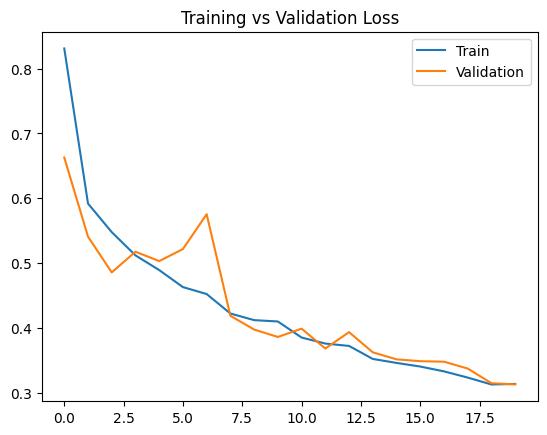

Test Accuracy of the model on the test images: 0.872


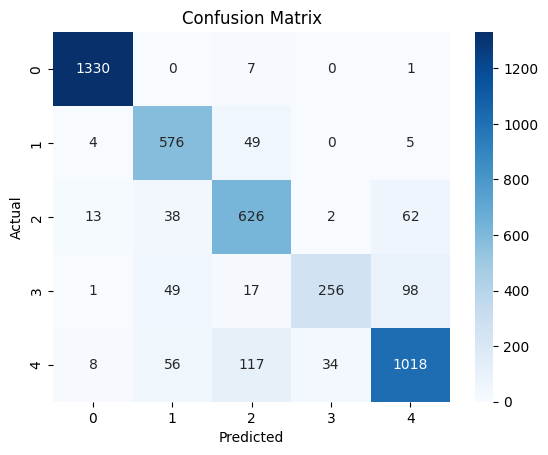

Optimiser: Adam, Learning rate: 0.001 -> Accuracy: 0.872
Epoch [1/20] Train Loss: 1.1181 Val Loss: 0.9911
Epoch [2/20] Train Loss: 0.8900 Val Loss: 0.8176
Epoch [3/20] Train Loss: 0.8020 Val Loss: 0.7323
Epoch [4/20] Train Loss: 0.7506 Val Loss: 0.6984
Epoch [5/20] Train Loss: 0.7240 Val Loss: 0.7625
Epoch [6/20] Train Loss: 0.7060 Val Loss: 0.7630
Epoch [7/20] Train Loss: 0.6906 Val Loss: 0.7802
Epoch [8/20] Train Loss: 0.6783 Val Loss: 0.6616
Epoch [9/20] Train Loss: 0.6714 Val Loss: 0.6834
Epoch [10/20] Train Loss: 0.6635 Val Loss: 0.7202
Epoch [11/20] Train Loss: 0.6729 Val Loss: 0.6688
Epoch [12/20] Train Loss: 0.6687 Val Loss: 0.6633
Epoch [13/20] Train Loss: 0.6622 Val Loss: 0.6714
Epoch [14/20] Train Loss: 0.6633 Val Loss: 0.7631
Epoch [15/20] Train Loss: 0.6544 Val Loss: 0.6699
Epoch [16/20] Train Loss: 0.6473 Val Loss: 0.6608
Epoch [17/20] Train Loss: 0.6447 Val Loss: 0.6924
Epoch [18/20] Train Loss: 0.6364 Val Loss: 0.6456
Epoch [19/20] Train Loss: 0.6355 Val Loss: 0.6895
Ep

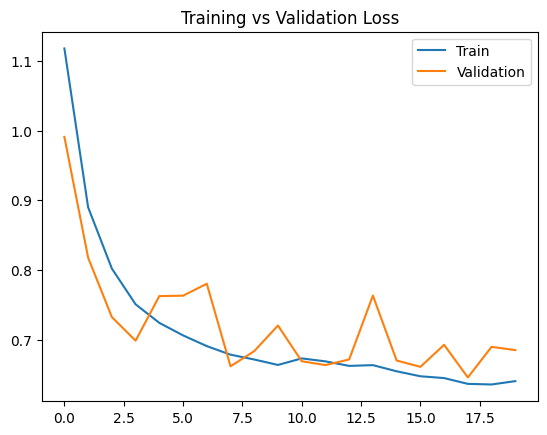

Test Accuracy of the model on the test images: 0.722


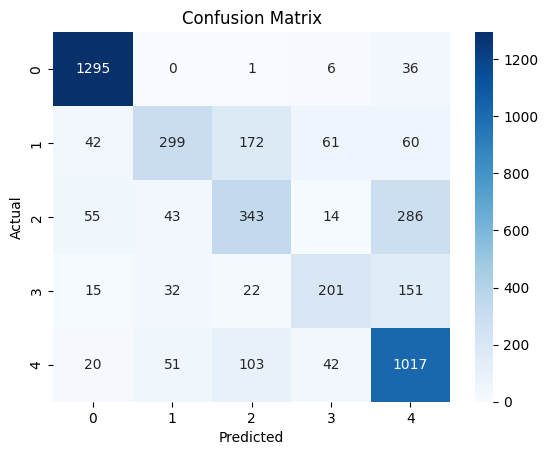

Optimiser: Adam, Learning rate: 0.01 -> Accuracy: 0.722
Epoch [1/20] Train Loss: 1.2087 Val Loss: 0.9586
Epoch [2/20] Train Loss: 0.8686 Val Loss: 0.7864
Epoch [3/20] Train Loss: 0.7468 Val Loss: 0.6910
Epoch [4/20] Train Loss: 0.6821 Val Loss: 0.6567
Epoch [5/20] Train Loss: 0.6466 Val Loss: 0.6405
Epoch [6/20] Train Loss: 0.6276 Val Loss: 0.6046
Epoch [7/20] Train Loss: 0.6072 Val Loss: 0.6107
Epoch [8/20] Train Loss: 0.5994 Val Loss: 0.5915
Epoch [9/20] Train Loss: 0.5855 Val Loss: 0.6026
Epoch [10/20] Train Loss: 0.5761 Val Loss: 0.5610
Epoch [11/20] Train Loss: 0.5670 Val Loss: 0.5765
Epoch [12/20] Train Loss: 0.5594 Val Loss: 0.5476
Epoch [13/20] Train Loss: 0.5515 Val Loss: 0.5942
Epoch [14/20] Train Loss: 0.5460 Val Loss: 0.5492
Epoch [15/20] Train Loss: 0.5413 Val Loss: 0.5270
Epoch [16/20] Train Loss: 0.5302 Val Loss: 0.5175
Epoch [17/20] Train Loss: 0.5276 Val Loss: 0.5239
Epoch [18/20] Train Loss: 0.5214 Val Loss: 0.5141
Epoch [19/20] Train Loss: 0.5191 Val Loss: 0.5182
Epo

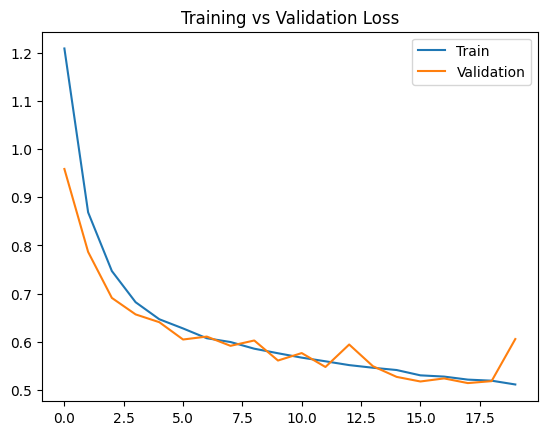

Test Accuracy of the model on the test images: 0.779


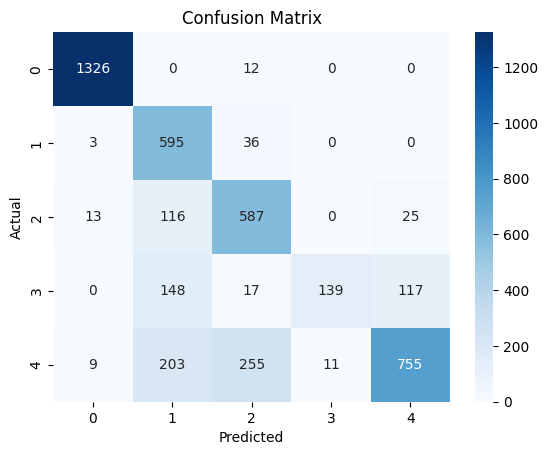

Optimiser: Adam, Learning rate: 0.0001 -> Accuracy: 0.779
Epoch [1/20] Train Loss: 0.8954 Val Loss: 0.6850
Epoch [2/20] Train Loss: 0.6229 Val Loss: 0.5567
Epoch [3/20] Train Loss: 0.5626 Val Loss: 0.5898
Epoch [4/20] Train Loss: 0.5164 Val Loss: 0.5322
Epoch [5/20] Train Loss: 0.4816 Val Loss: 0.4489
Epoch [6/20] Train Loss: 0.4599 Val Loss: 0.5619
Epoch [7/20] Train Loss: 0.4350 Val Loss: 0.4071
Epoch [8/20] Train Loss: 0.4325 Val Loss: 0.4075
Epoch [9/20] Train Loss: 0.4053 Val Loss: 0.4058
Epoch [10/20] Train Loss: 0.3976 Val Loss: 0.4001
Epoch [11/20] Train Loss: 0.3842 Val Loss: 0.4385
Epoch [12/20] Train Loss: 0.3734 Val Loss: 0.3835
Epoch [13/20] Train Loss: 0.3623 Val Loss: 0.5164
Epoch [14/20] Train Loss: 0.3514 Val Loss: 0.4019
Epoch [15/20] Train Loss: 0.3403 Val Loss: 0.3420
Epoch [16/20] Train Loss: 0.3250 Val Loss: 0.3778
Epoch [17/20] Train Loss: 0.3196 Val Loss: 0.3384
Epoch [18/20] Train Loss: 0.3168 Val Loss: 0.3750
Epoch [19/20] Train Loss: 0.3045 Val Loss: 0.3144
E

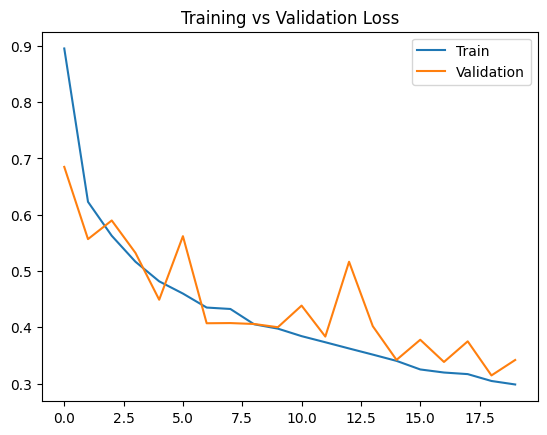

Test Accuracy of the model on the test images: 0.882


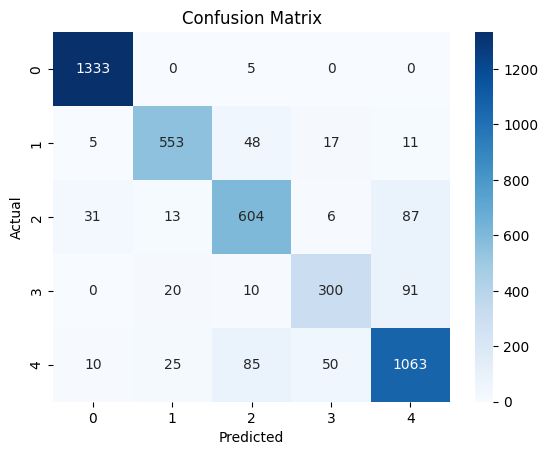

Optimiser: AdamW, Learning rate: 0.001 -> Accuracy: 0.882
Epoch [1/20] Train Loss: 1.1674 Val Loss: 1.0592
Epoch [2/20] Train Loss: 0.9235 Val Loss: 0.8767
Epoch [3/20] Train Loss: 0.8421 Val Loss: 0.7830
Epoch [4/20] Train Loss: 0.7754 Val Loss: 0.7189
Epoch [5/20] Train Loss: 0.7370 Val Loss: 0.7470
Epoch [6/20] Train Loss: 0.7079 Val Loss: 0.6844
Epoch [7/20] Train Loss: 0.6831 Val Loss: 0.6530
Epoch [8/20] Train Loss: 0.6823 Val Loss: 0.6455
Epoch [9/20] Train Loss: 0.6573 Val Loss: 0.6180
Epoch [10/20] Train Loss: 0.6373 Val Loss: 0.6058
Epoch [11/20] Train Loss: 0.6300 Val Loss: 0.9024
Epoch [12/20] Train Loss: 0.6203 Val Loss: 0.6509
Epoch [13/20] Train Loss: 0.6042 Val Loss: 0.5764
Epoch [14/20] Train Loss: 0.6046 Val Loss: 0.5673
Epoch [15/20] Train Loss: 0.5962 Val Loss: 0.5646
Epoch [16/20] Train Loss: 0.5974 Val Loss: 0.6007
Epoch [17/20] Train Loss: 0.5825 Val Loss: 0.5716
Epoch [18/20] Train Loss: 0.5867 Val Loss: 0.5469
Epoch [19/20] Train Loss: 0.5802 Val Loss: 0.5549
E

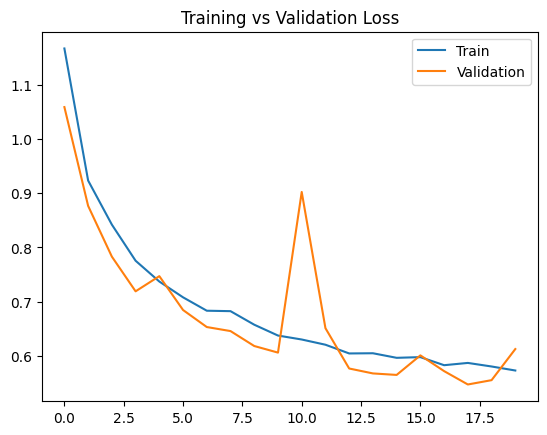

Test Accuracy of the model on the test images: 0.777


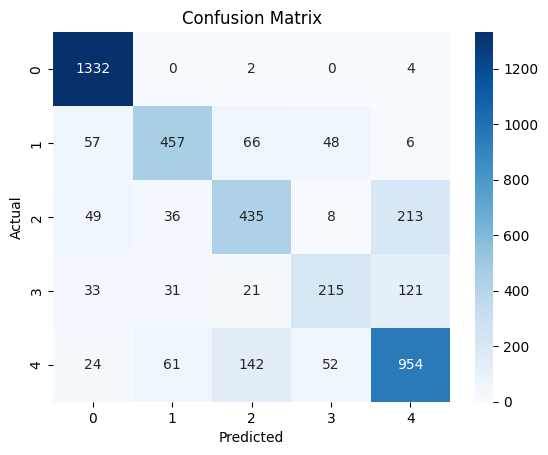

Optimiser: AdamW, Learning rate: 0.01 -> Accuracy: 0.777
Epoch [1/20] Train Loss: 1.1928 Val Loss: 0.9721
Epoch [2/20] Train Loss: 0.8989 Val Loss: 0.8175
Epoch [3/20] Train Loss: 0.7762 Val Loss: 0.7595
Epoch [4/20] Train Loss: 0.7139 Val Loss: 0.6825
Epoch [5/20] Train Loss: 0.6739 Val Loss: 0.6468
Epoch [6/20] Train Loss: 0.6538 Val Loss: 0.6296
Epoch [7/20] Train Loss: 0.6313 Val Loss: 0.6256
Epoch [8/20] Train Loss: 0.6172 Val Loss: 0.6334
Epoch [9/20] Train Loss: 0.6098 Val Loss: 0.6132
Epoch [10/20] Train Loss: 0.5962 Val Loss: 0.6000
Epoch [11/20] Train Loss: 0.5881 Val Loss: 0.5863
Epoch [12/20] Train Loss: 0.5820 Val Loss: 0.5740
Epoch [13/20] Train Loss: 0.5767 Val Loss: 0.5690
Epoch [14/20] Train Loss: 0.5699 Val Loss: 0.5534
Epoch [15/20] Train Loss: 0.5637 Val Loss: 0.5592
Epoch [16/20] Train Loss: 0.5608 Val Loss: 0.5493
Epoch [17/20] Train Loss: 0.5574 Val Loss: 0.5693
Epoch [18/20] Train Loss: 0.5525 Val Loss: 0.5502
Epoch [19/20] Train Loss: 0.5473 Val Loss: 0.5362
Ep

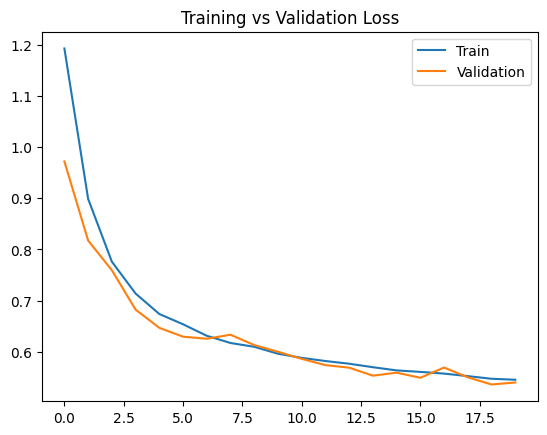

Test Accuracy of the model on the test images: 0.796


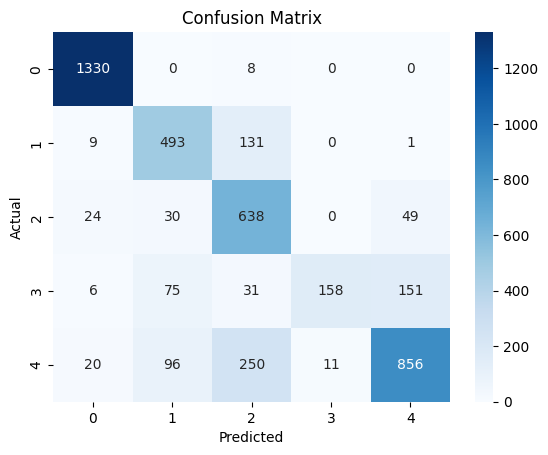

Optimiser: AdamW, Learning rate: 0.0001 -> Accuracy: 0.796


In [48]:
learning_rates = [0.001, 0.01, 0.0001]
epochs_list = [10, 20]
optimizer_names = ['SGD', 'Adam', 'AdamW'] 

results = []

for epoch in epochs_list:
    for optim_name in optimizer_names:
        for learn_rate in learning_rates:
            # Reinitialise model
            cnn = CNN().to(device)
            criterion = nn.CrossEntropyLoss()

            optimizer = None
            if optim_name == "SGD":
                optimizer = optim.SGD(cnn.parameters(), lr=learn_rate)
            elif optim_name == "Adam":
                optimizer = optim.Adam(cnn.parameters(), lr=learn_rate)
            else:
                optimizer = optim.AdamW(cnn.parameters(), lr=learn_rate)
            
            losses = train(epoch, cnn, loaders, loss_func, optimizer)
            acc, preds, labels = test(cnn)

            print(f"Optimiser: {optim_name}, Learning rate: {learn_rate} -> Accuracy: {acc:.3f}")

            results.append({
                'optimizer': optim_name,
                'lr': learn_rate,
                'epochs': epoch,
                'accuracy': acc,
                'losses': losses,
                'model': cnn,
                'preds': preds,
                'labels': labels
            })

In [49]:
import pandas as pd

df = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ['model','losses','preds','labels']}
     for r in results]
)
print(df.sort_values('accuracy', ascending=False).to_string(index=False))

optimizer     lr  epochs  accuracy
    AdamW 0.0010      20  0.882299
     Adam 0.0010      20  0.871537
     Adam 0.0010      10  0.870850
    AdamW 0.0010      10  0.853675
    AdamW 0.0001      20  0.795741
    AdamW 0.0001      10  0.794596
     Adam 0.0100      10  0.793680
     Adam 0.0001      10  0.782688
     Adam 0.0001      20  0.779025
    AdamW 0.0100      20  0.776964
      SGD 0.0100      20  0.761621
     Adam 0.0100      20  0.722464
      SGD 0.0100      10  0.712846
      SGD 0.0010      20  0.539043
      SGD 0.0010      10  0.530341
      SGD 0.0001      20  0.287841
    AdamW 0.0100      10  0.282345
      SGD 0.0001      10  0.282345


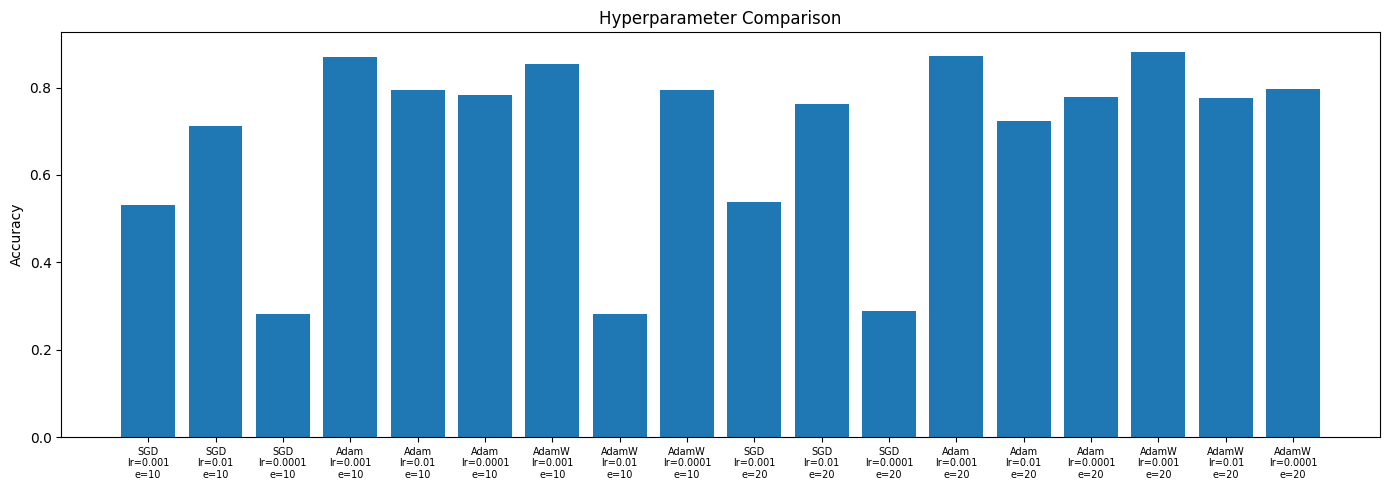

In [50]:
plt.figure(figsize=(14, 5))
plt.bar(range(len(results)), [r['accuracy'] for r in results])
plt.xticks(
    range(len(results)),
    [f"{r['optimizer']}\nlr={r['lr']}\ne={r['epochs']}" for r in results],
    fontsize=7
)
plt.ylabel('Accuracy')
plt.title('Hyperparameter Comparison')
plt.tight_layout()
plt.show()


Best → AdamW | LR=0.001 | Epochs=20 | Acc=0.882


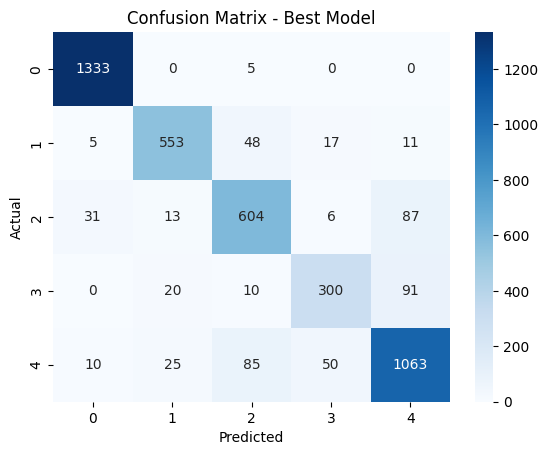

In [51]:
best = max(results, key=lambda x: x['accuracy'])
print(f"\nBest → {best['optimizer']} | LR={best['lr']} | Epochs={best['epochs']} | Acc={best['accuracy']:.3f}")

cm = confusion_matrix(best['labels'], best['preds'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Best Model')
plt.show()

## 7. Final Model Comparison

The best CNN configuration is compared against the logistic regression baseline using test accuracy.

In [52]:
max_index = df['accuracy'].idxmax()
full_row = df.loc[max_index]

print(full_row)

optimizer       AdamW
lr              0.001
epochs             20
accuracy     0.882299
Name: 15, dtype: object


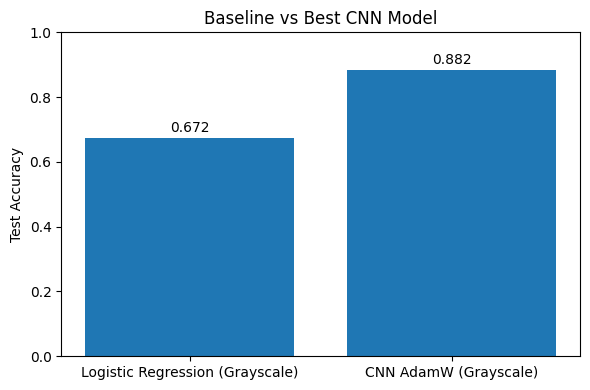

In [53]:

models = ['Logistic Regression (Grayscale)', f"CNN {full_row['optimizer']} (Grayscale)"]
accuracies = [test_acc_gray, df['accuracy'].max()
]

plt.figure(figsize=(6, 4))
plt.bar(models, accuracies)
plt.ylim(0, 1)
plt.ylabel('Test Accuracy')
plt.title('Baseline vs Best CNN Model')

# show values on bars
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.02, f"{acc:.3f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()